fraction explained:  [0.92461872 0.05306648 0.01710261 0.00521218]


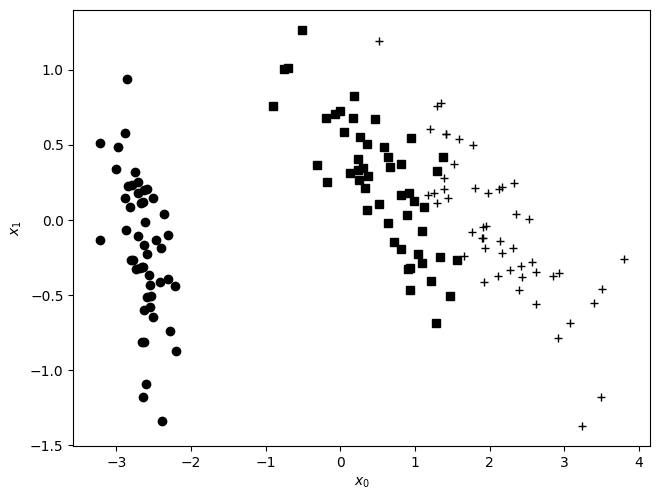

In [ ]:
import numpy as np
import matplotlib.pylab as plt
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.datasets import load_iris
from scipy.linalg import svd as SVD

# ----------------------------------------------------
# 1. 데이터 로드 및 전처리 (센터링)
# ----------------------------------------------------
iris = load_iris().data.copy()      # 아이리스 feature 데이터 복사 (150 샘플 x 4 특징값)
labels = load_iris().target.copy()  # 아이리스 품종 라벨 (0, 1, 2) 복사
m = iris.mean(axis=0)               # 각 특징값(열)의 평균 계산
s = iris.std(axis=0)                # 각 특징값(열)의 표준편차 계산
ir = iris - m                       # 데이터 센터링 (평균을 0으로 만들어 원점 중심 정렬)

# ----------------------------------------------------
# 2. 고유값 분해(Eigenvalue Decomposition) 기반 수동 PCA 구현
# ----------------------------------------------------
# 센터링된 데이터의 공분산 행렬 계산 (rowvar=False는 열을 변수로 간주함)
cv = np.cov(ir, rowvar=False)

# 공분산 행렬에 대한 고유값(val)과 고유벡터(vec) 계산
val, vec = np.linalg.eig(cv)
val = np.abs(val)                   # 고유값의 절대값 취함

# 고유값을 내림차순(가장 큰 값이 처음에 오도록)으로 정렬하기 위한 인덱스 계산
idx = np.argsort(val)[::-1]

# 각 주성분이 전체 분산을 설명하는 비율(설명 분산 비) 계산 및 출력
ex = val[idx] / val.sum()
print("fraction explained: ", ex)

# 가장 큰 고유값 2개에 해당되는 고유벡터를 행으로 쌓아서 투영 행렬 W(2x4) 생성
w = np.vstack((vec[:,idx[0]],vec[:,idx[1]]))

# 투영 행렬 W를 이용해 4차원 데이터를 2차원 공간으로 선형 사영(Projection)
d = np.zeros((ir.shape[0],2))
for i in range(ir.shape[0]):
    d[i,:] = np.dot(w,ir[i])     # W행렬과 각 샘플 벡터의 내적으로 신규 차원 축 좌표 계산

# 꽃 품종별 마커 지정(o, s, +) 후, 2차원 주성분 평면에 시각화
markers = np.array(["o","s","+"])[labels]
for i in range(len(labels)):
    plt.plot(d[i,0], d[i,1], marker=markers[i], color='k', linestyle='none')
plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig("iris_pca.png", dpi=300) # 수동 PCA 결과 이미지 파일 저장
plt.close()

# ----------------------------------------------------
# 3. Scikit-Learn 라이브러리의 PCA 클래스를 이용한 알고리즘 수행
# ----------------------------------------------------
pca = PCA(n_components=2)            # 주성분 크기를 2차원으로 설정한 PCA 인스턴스 생성
pca.fit(ir)                         # 센터링된 데이터 피팅 및 주성분 학습
dd = pca.fit_transform(ir)          # 학습 후 차원 축소 적용 (fit 와 transform을 한번에)

# Scikit-Learn PCA 결과 시각화
for i in range(len(labels)):
    plt.plot(dd[i,0], dd[i,1], marker=markers[i], color='k', linestyle='none')
plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig("iris_pca_sklearn.png", dpi=300) # Scikit-Learn PCA 이미지 저장
plt.close()

# ----------------------------------------------------
# 4. Scikit-Learn 라이브러리의 TruncatedSVD를 이용한 PCA 구현
# ----------------------------------------------------
svd = TruncatedSVD(n_components=2)  # 특이값 개수를 2개로 제한한 SVD 인스턴스 설계
svd.fit(ir)                         # 특이벡터 및 피처 공간 분석
s = svd.fit_transform(ir)           # 2차원 특이값 축으로 사영 및 데이터 변환

# TruncatedSVD 결과 시각화 (이미 센터링 되었으므로 PCA 결과와 일치)
for i in range(len(labels)):
    plt.plot(s[i,0], s[i,1], marker=markers[i], color='k', linestyle='none')
plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig("iris_pca_sklearn_svd.png", dpi=300) # TruncatedSVD 이미지 저장
plt.close()

# ----------------------------------------------------
# 5. SciPy의 SVD 라이브러리를 통해 수동 SVD 및 슬라이싱(Truncate)으로 PCA 구현
# ----------------------------------------------------
#  truncate manually - exact result as sklearn PCA
n_elements = 2
u,s_val,vt = SVD(ir)              # 센터링된 데이터 ir에 대해 SVD(U, s, Vt) 연산 수행

# 입력 피처와 크기가 같은 대각 특이치 행렬 S 구성
S = np.zeros((ir.shape[0], ir.shape[1]))
for i in range(4):
    S[i,i] = s_val[i]

# 중요도가 높은 상위 2개의 특이치 열만 남겨 특이치 절단(Truncate) 진행
S = S[:, :n_elements]

# 고유차원에 샘플 공간 U 대입 및 최종 투영 좌표 계산 (T = U @ S)
T = u @ S

# 수동 SVD 기반 PCA 차원 축소 결과 시각화
for i in range(len(labels)):
    plt.plot(T[i,0], T[i,1], marker=markers[i], color='k', linestyle='none')
plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig("iris_pca_truncated_svd.png", dpi=300) # 수동 SVD 차원 축소 이미지 저장

제시된 코드는 **아이리스(Iris, 붓꽃) 데이터를 주성분 분석(PCA)을 활용해 차원 축소하는 다양한 방법들**을 실습하고 비교하는 코드입니다. 

총 4가지 접근 방식으로 데이터를 4차원에서 2차원으로 축소하고 있습니다. 사용된 핵심 함수 및 라이브러리의 사용법과 함께 단계별로 핵심을 짚어드리겠습니다.

---

### [1단계] 데이터 전처리 및 수동 고윳값 분해(Eigenvalue Decomposition) PCA
첫 번째 블록은 외부 패키지 도움 없이 선형대수 수식을 직접 코드로 옮겨 차원을 축소하는 과정입니다.

```python
iris = load_iris().data.copy()
labels = load_iris().target.copy()

# 1. 평균(Mean) 계산 및 센터링(Centering)
m = iris.mean(axis=0)
ir = iris - m  # 각 변수의 평균을 0으로 만들어 원점이 중심에 오게 조정

# 2. 공분산 행렬 계산
cv = np.cov(ir, rowvar=False) 
# np.cov(m, rowvar=False): 행(row)이 샘플이고 열(column)이 변수일 때 False로 설정합니다.

# 3. 고윳값(Eigenvalue)과 고유벡터(Eigenvector) 계산
val, vec = np.linalg.eig(cv)
val = np.abs(val)

# 4. 고윳값이 큰 순서대로 내림차순 정렬
idx = np.argsort(val)[::-1] 
# np.argsort(): 오름차순으로 인덱스를 반환하므로 [::-1] 역순 정렬을 결합해 큰 인덱스를 추려냅니다.

# 설명을 얼마나 담고 있는지 비율(Fraction) 계산
ex = val[idx] / val.sum()
print("fraction explained: ", ex)

# 5. 가장 큰 고유벡터 2개를 선택해 투영 행렬 W 구성
w = np.vstack((vec[:, idx[0]], vec[:, idx[1]]))

# 6. 원본 데이터를 주성분 축으로 선형 변환(Projection)
d = np.zeros((ir.shape[0], 2))
for i in range(ir.shape[0]):
    d[i, :] = np.dot(w, ir[i])  # 벡터 내적을 통한 2차원 투영
```

- **`np.cov(data, rowvar=False)`**: 변수 간의 분산 및 공분산 관계를 기술하는 행렬을 만듭니다. `rowvar=False`는 열(column) 단위가 변수임을 지정합니다.
- **`np.linalg.eig(matrix)`**: 대칭행렬(공분산 행렬)을 매개변수로 받아 고윳값(eigenvalue) 배열과 고유벡터(eigenvector) 행렬을 쌍으로 반환합니다.
- **`np.vstack((a, b))`**: 수평 벡터들을 세로로 쌓아(Vertical stack) 변환 행렬을 구축합니다.

---

### [2단계] Scikit-Learn `PCA` 이용하기
복잡한 선형대수 과정을 함수 하나로 간편하게 단축하여 동일한 결과를 얻는 방법입니다.

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # 2차원으로 축소하겠다고 차원 개수 지정
pca.fit(ir)               # 전처리된 데이터 fiting (주성분 분석 완료)
dd = pca.transform(ir)    # 변환 적용 (fit_transform을 써서 한 번에 수행 가능)
```

- **`PCA(n_components)`**: 축소할 목표 주성분의 수(`n_components`)를 지정하여 객체를 생성합니다.
- **`fit(X)`**: 데이터의 주성분 방향(고유벡터)과 설명 분산량(고윳값)을 찾아 학습시킵니다.
- **`transform(X)` / `fit_transform(X)`**: 분석된 주성분 방향으로 원래 데이터를 직교 투영(Orthogonal projection)하여 차원이 축소된 데이터를 반환합니다.

---

### [3단계] Scikit-Learn `TruncatedSVD` 이용하기
`TruncatedSVD`는 희소 행렬(Sparse matrix)이나 큰 차원의 데이터에서 행렬의 중심을 이동시키지 않고 빠르게 차원을 선별 축소하는 특이값 분해(SVD) 기법입니다.

```python
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2) # 축소 차원 개수 지정
svd.fit(ir)
s = svd.fit_transform(ir)          # 데이터 투영
```

- **`TruncatedSVD(n_components)`**: SVD 결과 중 가장 큰 $k$개의 특이값에 해당하는 부분만 잘라내어 차원을 축소합니다.
- **PCA와의 차이점**: 데이터 센터링($X - \text{mean}$)을 내부적으로 기본 처리하지 않습니다. 여기서는 이미 전처리 단계에서 센터링된 데이터 `ir`을 넣었기 때문에 PCA와 계산상 결과가 똑같이 나옵니다.

---

### [4단계] SciPy `svd`를 통한 수동 특이값 분해(SVD) 차원 축소
특이값 분해(Singular Value Decomposition)의 기본 수식 $A = U \Sigma V^T$ 관계식을 직접 계산하여 PCA 결과를 정밀 재현하는 과정입니다.

```python
from scipy.linalg import svd as SVD

# 1. 특이값 분해 수행
u, s_val, vt = SVD(ir)

# 2. 특이값 사각 대각 행렬 S 재생성 (샘플 수 x 피처 수 크기)
S = np.zeros((ir.shape[0], ir.shape[1]))
for i in range(4):
    S[i, i] = s_val[i]

# 3. 우측 절단(Truncation) 수행 (가장 영향력 있는 특이값 2열만 유지)
S = S[:, :n_elements] # n_elements = 2

# 4. 축소된 차원으로 투영
T = u @ S # 행렬 곱 연산 기호(@)를 활용해 최종 축소 변환 완료 (U와 S의 곱)
```

- **`SVD(data)`**: 데이터 행렬을 왼쪽 특이벡터 $U$(샘플의 관계), 특이값 $s\_val$(각 성분의 중요도), 오른쪽 특이벡터 $V^T$(피처의 무리 구성)로 삼중 분해합니다.
- **`T = u @ S`**: SVD 수식에 의해 $X V = U \Sigma$ 가 최적 투영 공간 좌표가 됩니다. 이 중 상위 2개의 스펙트럼 성분 벡터 공간만 전개($U \Sigma_{truncated}$)하여 차원을 줄였습니다. 이식하여 PCA 결과와 한 치의 오차도 없는 차원 공간을 만들어냅니다.